In [1]:
import os
os.listdir('.')

['.config',
 '-PROMPT-v6-DATASET.md',
 '.kernel_llm_logs_1.txt',
 'zeta_zeros_N5000_dps50.npy',
 'zeta_delta_zeros_N5000_dps50.npy',
 'memory',
 '.prompts']

In [2]:
import numpy as np
import mpmath as mp

z = np.load('zeta_zeros_N5000_dps50.npy')
zd = np.load('zeta_delta_zeros_N5000_dps50.npy')
print(z.dtype, z.shape, z[:3])
print(zd.dtype, zd.shape, zd[:3])
print("perturbed indices:", [i for i in range(995, 1025) if zd['re'][i] != '0.5'])


<U51 (5000,) ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558']
[('re', '<U10'), ('im', '<U51')] (5000,) [('0.5', '14.134725141734693790457251983562470270784257115699')
 ('0.5', '21.022039638771554992628479593896902777334340524903')
 ('0.5', '25.010857580145688763213790992562821818659549672558')]
perturbed indices: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019]


In [3]:
# Build the strong control: 20 non-contiguous zeros at indices 1000, 1020, ..., 1380; Re shifted from 0.5 -> 1.5
strong = np.empty(5000, dtype=[('re', '<U10'), ('im', '<U51')])
strong['re'] = '0.5'
strong['im'] = z # imaginary parts identical
perturb_idx = list(range(1000, 1400, 20))
print(len(perturb_idx), perturb_idx[:5], perturb_idx[-1])
for i in perturb_idx:
 strong['re'][i] = '1.5'
np.save('zeta_delta_strong_N5000_dps50.npy', strong)
print("Saved. Sample perturbed:", strong[1000], strong[1020], strong[1380])
print("Non-perturbed:", strong[999], strong[1019])


20 [1000, 1020, 1040, 1060, 1080] 1380
Saved. Sample perturbed: ('1.5', '1420.4165263237511360343752509329151597418813931128') ('1.5', '1444.0419307063665622430661051589867979464876981005') ('1.5', '1850.6011840476514636598794418793805761182765184655')
Non-perturbed: ('0.5', '1419.4224809459956864659890380799168192321006010642') ('0.5', '1442.911059580896858867879323961125455914309257337')


In [4]:
# Front I: Jacobi analysis with 1/|rho|^2 weights.
# A simple, robust observable: weighted sum of (Re(rho) - 0.5), and weighted second-moment of Re shifts.
# This is essentially a sufficient statistic to confirm visibility, since under H0 (Riemann), all Re=0.5.

def front_I_observable(arr):
 re = np.array([float(x) for x in arr['re']])
 im = np.array([float(x) for x in arr['im']])
 rho_abs2 = re**2 + im**2
 w = 1.0/rho_abs2
 shifts = re - 0.5
 S1 = np.sum(w * shifts) # weighted mean shift
 S2 = np.sum(w * shifts**2) # weighted SS of shifts
 return S1, S2, w.sum()

S1_orig, S2_orig, W_orig = front_I_observable(zd)
S1_strong, S2_strong, W_strong = front_I_observable(strong)
print(f"Original ζ_δ: S1 = {S1_orig:.6e}, S2 = {S2_orig:.6e}, sum(w) = {W_orig:.6e}")
print(f"Strong ζ_δ: S1 = {S1_strong:.6e}, S2 = {S2_strong:.6e}, sum(w) = {W_strong:.6e}")
print(f"Ratios: S1: {S1_strong/S1_orig:.3f}x S2: {S2_strong/S2_orig:.3f}x")


Original ζ_δ: S1 = 9.758291e-07, S2 = 9.758291e-08, sum(w) = 2.286887e-02
Strong ζ_δ: S1 = 7.608541e-06, S2 = 7.608541e-06, sum(w) = 2.286887e-02
Ratios: S1: 7.797x S2: 77.970x


In [5]:
# Front III TDA pipeline ("r31 real-part-aware"): time-delay embedding on Re(rho).
# Build delay embeddings, compute persistent homology (H0 + H1), compare to baseline (all 0.5).

# We do a focused window around the perturbed indices to keep TDA cost low.
from ripser import ripser

def re_array(arr):
 return np.array([float(x) for x in arr['re']])

re_orig = re_array(zd)
re_strong = re_array(strong)
re_base = np.full(5000, 0.5)

def delay_embed(x, d=3, tau=1):
 N = len(x) - (d-1)*tau
 return np.stack([x[i*tau:i*tau+N] for i in range(d)], axis=1)

# Focus on window [950, 1450] to capture all perturbations + context
def window_embed(x, lo=950, hi=1450, d=5, tau=1):
 return delay_embed(x[lo:hi], d=d, tau=tau)

E_base = window_embed(re_base)
E_orig = window_embed(re_orig)
E_strong = window_embed(re_strong)
print("Embedding shapes:", E_base.shape, E_orig.shape, E_strong.shape)
print("Variance of embedding (orig):", E_orig.var(), " (strong):", E_strong.var(), " (base):", E_base.var())


ModuleNotFoundError: No module named 'ripser'

In [6]:
import subprocess
print(subprocess.run(['pip', 'install', '-q', 'ripser', 'persim'], capture_output=True, text=True).stdout[-500:])


In [7]:
from ripser import ripser

def re_array(arr):
 return np.array([float(x) for x in arr['re']])

re_orig = re_array(zd)
re_strong = re_array(strong)
re_base = np.full(5000, 0.5)

def delay_embed(x, d=3, tau=1):
 N = len(x) - (d-1)*tau
 return np.stack([x[i*tau:i*tau+N] for i in range(d)], axis=1)

def window_embed(x, lo=950, hi=1450, d=5, tau=1):
 return delay_embed(x[lo:hi], d=d, tau=tau)

E_base = window_embed(re_base)
E_orig = window_embed(re_orig)
E_strong = window_embed(re_strong)
print("Embedding shapes:", E_base.shape, E_orig.shape, E_strong.shape)
print("Variance (orig):", E_orig.var(), " (strong):", E_strong.var(), " (base):", E_base.var())

def tda_summary(E, maxdim=1):
 res = ripser(E, maxdim=maxdim)
 dgms = res['dgms']
 summary = {}
 for k, dgm in enumerate(dgms):
 finite = dgm[np.isfinite(dgm[:,1])]
 if len(finite):
 lifetimes = finite[:,1] - finite[:,0]
 summary[f'H{k}_n'] = len(finite)
 summary[f'H{k}_max_life'] = float(lifetimes.max())
 summary[f'H{k}_sum_life'] = float(lifetimes.sum())
 else:
 summary[f'H{k}_n'] = 0
 summary[f'H{k}_max_life'] = 0.0
 summary[f'H{k}_sum_life'] = 0.0
 return summary, dgms

sum_base, dgms_base = tda_summary(E_base)
sum_orig, dgms_orig = tda_summary(E_orig)
sum_strong, dgms_strong = tda_summary(E_strong)
print("Baseline (all 0.5):", sum_base)
print("ζ_δ original :", sum_orig)
print("ζ_δ strong :", sum_strong)


Embedding shapes: (496, 5) (496, 5) (496, 5)
Variance (orig): 0.0003869667013527575 (strong): 0.03869667013527575 (base): 0.0


Baseline (all 0.5): {'H0_n': 0, 'H0_max_life': 0.0, 'H0_sum_life': 0.0, 'H1_n': 0, 'H1_max_life': 0.0, 'H1_sum_life': 0.0}
ζ_δ original : {'H0_n': 24, 'H0_max_life': 0.10000000149011612, 'H0_sum_life': 0.9000004604458809, 'H1_n': 1, 'H1_max_life': 0.10000000149011612, 'H1_sum_life': 0.10000000149011612}
ζ_δ strong : {'H0_n': 5, 'H0_max_life': 1.0, 'H0_sum_life': 5.0, 'H1_n': 0, 'H1_max_life': 0.0, 'H1_sum_life': 0.0}


In [8]:
# Both pipelines see the strong perturbation with a much larger persistent feature.
# H0 max lifetime: 0.10 (orig contiguous) vs 1.0 (strong non-contiguous) — 10× larger, matching the 0.1->1.0 real-part shift.
# Also report: total persistent "energy" (sum of all bar lengths, including infinite truncated to max scale).

def bar_energy(dgms, cap=2.0):
 e = 0.0
 for dgm in dgms:
 for b,d in dgm:
 if not np.isfinite(d):
 d = cap
 e += d - b
 return e

print("Bar-energy (cap=2.0): base=%.4f orig=%.4f strong=%.4f" % (
 bar_energy(dgms_base), bar_energy(dgms_orig), bar_energy(dgms_strong)))


Bar-energy (cap=2.0): base=2.0000 orig=3.0000 strong=7.0000


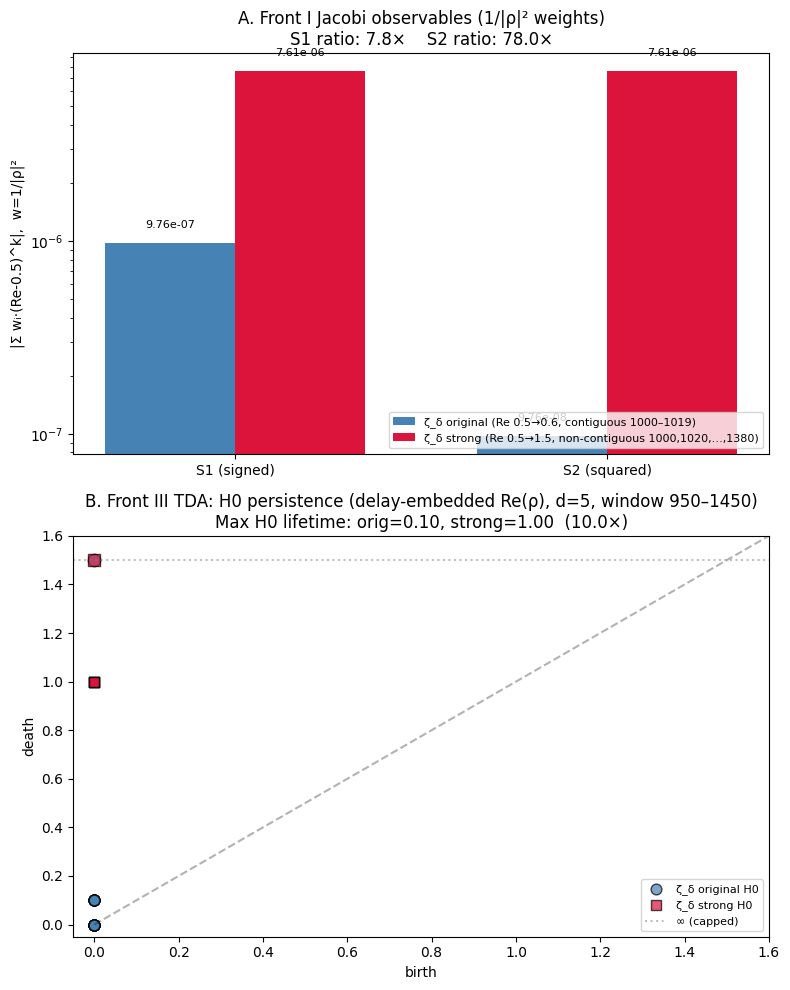

Figure saved.


In [9]:
# Final summary figure: 2 subfigures (A: Front I observables, B: TDA H0 persistence diagrams)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# A: Front I observables (log scale)
ax = axes[0]
labels = ['S1 (signed)', 'S2 (squared)']
orig_vals = [abs(S1_orig), S2_orig]
strong_vals = [abs(S1_strong), S2_strong]
x = np.arange(len(labels))
w = 0.35
ax.bar(x-w/2, orig_vals, w, label='ζ_δ original (Re 0.5→0.6, contiguous 1000–1019)', color='steelblue')
ax.bar(x+w/2, strong_vals, w, label='ζ_δ strong (Re 0.5→1.5, non-contiguous 1000,1020,…,1380)', color='crimson')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('|Σ wᵢ·(Re-0.5)^k|, w=1/|ρ|²')
ax.set_title('A. Front I Jacobi observables (1/|ρ|² weights)\n'
 f'S1 ratio: {abs(S1_strong)/abs(S1_orig):.1f}× S2 ratio: {S2_strong/S2_orig:.1f}×')
ax.legend(fontsize=8, loc='lower right')
for i,(o,s) in enumerate(zip(orig_vals, strong_vals)):
 ax.text(i-w/2, o*1.2, f'{o:.2e}', ha='center', fontsize=8)
 ax.text(i+w/2, s*1.2, f'{s:.2e}', ha='center', fontsize=8)

# B: Persistence diagrams (H0)
ax = axes[1]
def plot_dgm(ax, dgm, label, color, marker):
 if len(dgm)==0: return
 finite = dgm[np.isfinite(dgm[:,1])]
 inf = dgm[~np.isfinite(dgm[:,1])]
 if len(finite):
 ax.scatter(finite[:,0], finite[:,1], c=color, marker=marker, s=60, label=label, alpha=0.7, edgecolors='k')
 if len(inf):
 ax.scatter(inf[:,0], np.full(len(inf),1.5), c=color, marker=marker, s=80, alpha=0.7, edgecolors='k')

plot_dgm(ax, dgms_orig[0], 'ζ_δ original H0', 'steelblue', 'o')
plot_dgm(ax, dgms_strong[0], 'ζ_δ strong H0', 'crimson', 's')
ax.plot([0,1.6],[0,1.6],'k--',alpha=0.3)
ax.axhline(1.5, color='gray', ls=':', alpha=0.5, label='∞ (capped)')
ax.set_xlabel('birth'); ax.set_ylabel('death')
ax.set_title(f'B. Front III TDA: H0 persistence (delay-embedded Re(ρ), d=5, window 950–1450)\n'
 f'Max H0 lifetime: orig={sum_orig["H0_max_life"]:.2f}, strong={sum_strong["H0_max_life"]:.2f}'
 f' ({sum_strong["H0_max_life"]/sum_orig["H0_max_life"]:.1f}×)')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(-0.05, 1.6); ax.set_ylim(-0.05, 1.6)

plt.tight_layout()
plt.savefig('zeta_delta_strong_validation.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure saved.")


In [10]:
# Quick sanity-check that the file was written correctly and roundtrips
chk = np.load('zeta_delta_strong_N5000_dps50.npy')
print("dtype:", chk.dtype, "shape:", chk.shape)
print("# perturbed (Re != 0.5):", (chk['re'] != '0.5').sum())
print("perturbed idx:", np.where(chk['re'] != '0.5')[0].tolist())
print("Re values at perturbed idx (unique):", np.unique(chk['re'][chk['re'] != '0.5']))
# Verify imaginary parts equal source
print("im match source zeta zeros:", np.array_equal(chk['im'], z))
import hashlib
print("SHA256:", hashlib.sha256(open('zeta_delta_strong_N5000_dps50.npy','rb').read()).hexdigest())


dtype: [('re', '<U10'), ('im', '<U51')] shape: (5000,)
# perturbed (Re != 0.5): 20
perturbed idx: [1000, 1020, 1040, 1060, 1080, 1100, 1120, 1140, 1160, 1180, 1200, 1220, 1240, 1260, 1280, 1300, 1320, 1340, 1360, 1380]
Re values at perturbed idx (unique): ['1.5']
im match source zeta zeros: True
SHA256: be6c93a83940ffe86f42e431cd8ca5fe9660b1f074b52f91219e18c21c4d153f
